# DS 4320 Project 1: Predicting FEMA Housing Assistance Needs

**Author:** Vinith Jayamani  
**NetID:** uhe5bj  
**Date:** Spring 2026

## Overview

This notebook implements the full data pipeline for predicting whether a disaster-affected household will require habitability repairs, using FEMA's Individual Assistance Housing Registrants dataset.

### Pipeline steps
1. Load raw CSV into DuckDB
2. Clean and normalize into 4 relational tables
3. Exploratory SQL queries across joined tables
4. Build ML feature matrix
5. Train Random Forest classifier + Gradient Boosting regressor
6. Visualize and interpret results

### Problem
Following large-scale disasters, FEMA must determine which households need the most urgent interventions. This pipeline predicts habitability repair requirements from registration-time demographics and damage indicators, enabling more proactive resource allocation.

## 1. LOADING SCRIPT


In [3]:
## LOAD.PY — only change is logging setup
## WHAT CHANGED: replaced logging.basicConfig with a named logger
## so it works correctly when pasted into a Jupyter notebook cell
## (basicConfig is ignored after first call in same kernel session)
## Everything else is identical to your working version.

import duckdb
import logging
import os
import sys

CSV_PATH = "IndividualAssistanceHousingRegistrantsLargeDisasters.csv"
DB_PATH  = "fema.db"
LOG_PATH = "pipeline.log"

# ── LOGGING (notebook-safe version) ──
# Using a named logger instead of basicConfig so it reconfigures
# correctly even when run inside a Jupyter kernel
logger = logging.getLogger("fema_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()  # remove any handlers from previous cell runs
fh = logging.FileHandler(LOG_PATH)
fh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
sh = logging.StreamHandler(sys.stdout)
sh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
logger.addHandler(fh)
logger.addHandler(sh)

# HELPER FUNCTIONS

def check_csv_exists(path: str) -> None:
    """
    Verifies the CSV file exists before attempting to load.
    Raises FileNotFoundError with a helpful message if not found.
    """
    if not os.path.exists(path):
        logger.error(f"CSV file not found at: {path}")
        raise FileNotFoundError(
            f"\n\nCould not find the CSV at: {path}"
            f"\nPlease update CSV_PATH at the top of load.py to point to your file."
        )
    logger.info(f"CSV found: {path}")


def connect_to_db(db_path: str) -> duckdb.DuckDBPyConnection:
    """
    Creates or connects to a DuckDB database file.
    Returns the connection object.
    """
    try:
        con = duckdb.connect(db_path)
        logger.info(f"Connected to DuckDB database: {db_path}")
        return con
    except Exception as e:
        logger.error(f"Failed to connect to DuckDB: {e}")
        raise


def drop_existing_table(con: duckdb.DuckDBPyConnection, table_name: str) -> None:
    """
    Drops a table if it already exists so we can reload cleanly.
    Useful during development when you want to re-run the script.
    """
    try:
        con.execute(f"DROP TABLE IF EXISTS {table_name}")
        logger.info(f"Dropped existing table '{table_name}' (if it existed)")
    except Exception as e:
        logger.error(f"Failed to drop table '{table_name}': {e}")
        raise


def load_csv_to_duckdb(con: duckdb.DuckDBPyConnection, csv_path: str, table_name: str) -> None:
    """
    Reads the CSV into DuckDB using read_csv_auto.

    read_csv_auto is great for this dataset because:
      - It auto-detects column types
      - It handles the large file size efficiently (streams it, doesn't load all into RAM)
      - ignore_errors=True skips malformed rows without crashing
      - null_padding=True fills short rows with NULLs instead of erroring
    """
    try:
        logger.info(f"Loading CSV into table '{table_name}' — this may take a moment for a 979MB file...")
        con.execute(f"""
            CREATE TABLE {table_name} AS
            SELECT * FROM read_csv_auto(
                '{csv_path}',
                ignore_errors = TRUE,
                null_padding  = TRUE,
                header        = TRUE
            )
        """)
        logger.info(f"Successfully created table '{table_name}'")
    except Exception as e:
        logger.error(f"Failed to load CSV: {e}")
        raise


def print_data_summary(con: duckdb.DuckDBPyConnection, table_name: str) -> None:
    """
    Prints a quick summary of the loaded data:
      - Row and column counts
      - All column names and their inferred data types
      - Null counts per column
      - A few sample rows
    """
    logger.info("Generating data summary...")

    row_count = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    col_info  = con.execute(f"DESCRIBE {table_name}").fetchdf()
    col_count = len(col_info)

    print(f"  TABLE: {table_name}")
    print(f"  Rows : {row_count:,}")
    print(f"  Cols : {col_count}")

    print("\n── Column names & inferred types ──")
    print(col_info[["column_name", "column_type"]].to_string(index=False))

    print("\n── Null counts per column ──")
    null_query_parts = [
        f"SUM(CASE WHEN \"{col}\" IS NULL THEN 1 ELSE 0 END) AS \"{col}\""
        for col in col_info["column_name"]
    ]
    null_query  = f"SELECT {', '.join(null_query_parts)} FROM {table_name}"
    null_counts = con.execute(null_query).fetchdf().T
    null_counts.columns  = ["null_count"]
    null_counts["pct_null"] = (null_counts["null_count"] / row_count * 100).round(1)
    null_counts = null_counts[null_counts["null_count"] > 0].sort_values("pct_null", ascending=False)

    if null_counts.empty:
        print("  No nulls found — nice clean data!")
    else:
        print(null_counts.to_string())

    print("\n── First 3 rows (sample) ──")
    sample = con.execute(f"SELECT * FROM {table_name} LIMIT 3").fetchdf()
    print(sample.T.to_string())

    logger.info("Data summary complete")


def show_key_column_distributions(con: duckdb.DuckDBPyConnection, table_name: str) -> None:
    """
    Prints value distributions for key columns most important for our project.
    """
    print("── Key column distributions ──\n")

    key_columns = [
        ("ownRent",                    "Owner vs Renter split"),
        ("residenceType",              "Residence types"),
        ("damagedStateAbbreviation",   "Top 10 states"),
        ("rentalAssistanceEligible",   "Rental assistance eligible (ML target 1)"),
        ("habitabilityRepairsRequired","Habitability repairs required (ML target 2)"),
    ]

    for col, label in key_columns:
        try:
            print(f"  {label} [{col}]")
            result = con.execute(f"""
                SELECT
                    "{col}"    AS value,
                    COUNT(*)   AS count,
                    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
                FROM {table_name}
                WHERE "{col}" IS NOT NULL
                GROUP BY "{col}"
                ORDER BY count DESC
                LIMIT 10
            """).fetchdf()
            print(result.to_string(index=False))
            print()
        except Exception as e:
            logger.warning(f"Could not compute distribution for '{col}': {e}")


# MAIN

def main():
    """
    Main entry point:
      1. Verify CSV exists
      2. Connect to DuckDB
      3. Drop old table if re-running
      4. Load CSV into raw_fema table
      5. Print summary
      6. Show key column distributions
    """
    logger.info("load.py started...")

    check_csv_exists(CSV_PATH)
    con = connect_to_db(DB_PATH)
    drop_existing_table(con, "raw_fema")
    load_csv_to_duckdb(con, CSV_PATH, "raw_fema")
    print_data_summary(con, "raw_fema")
    show_key_column_distributions(con, "raw_fema")

    con.close()
    logger.info("load.py finished — database saved to: " + DB_PATH)
    print(f"✓ Database saved to: {DB_PATH}")
    print(f"✓ Log written to:    {LOG_PATH}")
    print(f"\nNext step: run clean.py to normalize into 4 tables")


if __name__ == "__main__":
    main()

2026-03-31 00:47:47,417 | INFO | load.py started...


INFO:fema_pipeline:load.py started...


2026-03-31 00:47:47,425 | INFO | CSV found: IndividualAssistanceHousingRegistrantsLargeDisasters.csv


INFO:fema_pipeline:CSV found: IndividualAssistanceHousingRegistrantsLargeDisasters.csv


2026-03-31 00:47:47,535 | INFO | Connected to DuckDB database: fema.db


...

  TABLE: raw_fema
  Rows : 6,367,325
  Cols : 42

── Column names & inferred types ──
                    column_name              column_type
                 disasterNumber                   BIGINT
                    damagedCity                  VARCHAR
       damagedStateAbbreviation                  VARCHAR
                 damagedZipCode                  VARCHAR
           householdComposition                   BIGINT
                    grossIncome                   BIGINT
                   specialNeeds                   BIGINT
                        ownRent                  VARCHAR
                  residenceType                  VARCHAR
            homeOwnersInsurance                   BIGINT
                 floodInsurance                   BIGINT
                      inspected                   BIGINT
                          rpfvl                   DOUBLE
    habitabilityRepairsRequired                   BIGINT
                      destroyed                   BIGINT
  

INFO:fema_pipeline:Data summary complete


── Key column distributions ──

  Owner vs Renter split [ownRent]
  value   count  pct
  Owner 3344322 52.5
 Renter 3004389 47.2
Unknown   18614  0.3

  Residence types [residenceType]
                   value   count  pct
            House/Duplex 3921011 61.6
               Apartment 1230502 19.3
             Mobile Home  458477  7.2
               Townhouse  266699  4.2
                   Other  254226  4.0
                   Condo  178227  2.8
          Travel Trailer   39280  0.6
Assisted Living Facility    8394  0.1
                    Boat    4267  0.1
        Military Housing    3139  0.0

  Top 10 states [damagedStateAbbreviation]
value   count  pct
   FL 2747706 43.2
   TX 1313342 20.6
   PR 1122624 17.6
   LA 1043805 16.4
   NC  139810  2.2
   SC       7  0.0
   GA       5  0.0
   MS       5  0.0
   MD       4  0.0
   VI       3  0.0

  Rental assistance eligible (ML target 1) [rentalAssistanceEligible]
 value   count  pct
     0 5359304 84.2
     1 1008021 15.8

  Habitabili

INFO:fema_pipeline:load.py finished — database saved to: fema.db


✓ Database saved to: fema.db
✓ Log written to:    pipeline.log

Next step: run clean.py to normalize into 4 tables


## 2. Clean and normalize into 4 relational tables

| Cleaning decision | Rationale |
|---|---|
| Filter `inspected=1` AND target not null | ML target only exists for inspected rows |
| Fill dollar NULLs with 0 | NULL means no damage — not unknown |
| Impute income with state median | 18% missing; state median preserves regional variation |
| Drop `highWaterLocation` | 100% null |
| Drop rental resource columns | 99.8% null, post-aid logistics |

In [4]:
## CLEAN.PY — only change is logging setup (same fix as load.py)
## WHAT CHANGED: replaced logging.basicConfig with named logger
## Everything else is identical to your working version.

import duckdb
import logging
import os
import sys

DB_PATH  = "fema.db"
LOG_PATH = "pipeline.log"
DATA_DIR = "data"

# ── LOGGING (notebook-safe version) ──
logger = logging.getLogger("fema_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fh = logging.FileHandler(LOG_PATH)
fh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
sh = logging.StreamHandler(sys.stdout)
sh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
logger.addHandler(fh)
logger.addHandler(sh)


# HELPER FUNCTIONS

def connect(db_path: str) -> duckdb.DuckDBPyConnection:
    """Connect to the existing fema.db created by load.py."""
    try:
        con = duckdb.connect(db_path)
        logger.info(f"Connected to {db_path}")
        return con
    except Exception as e:
        logger.error(f"Could not connect to {db_path}: {e}")
        raise


def ensure_data_dir(path: str) -> None:
    """Create the data/ output folder if it doesn't exist yet."""
    os.makedirs(path, exist_ok=True)
    logger.info(f"Output directory ready: {path}")


def drop_table(con: duckdb.DuckDBPyConnection, name: str) -> None:
    """Drop a table if it exists so clean.py is safe to re-run."""
    try:
        con.execute(f"DROP TABLE IF EXISTS {name}")
        logger.info(f"Dropped existing table: {name}")
    except Exception as e:
        logger.error(f"Failed to drop {name}: {e}")
        raise


def row_count(con: duckdb.DuckDBPyConnection, table: str) -> int:
    """Return the number of rows in a table."""
    return con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]


# STEP 1 — BUILD CLEANED BASE TABLE

def build_cleaned_base(con: duckdb.DuckDBPyConnection) -> None:
    """
    Creates fema_clean from raw_fema by applying all cleaning rules.

    Cleaning decisions:
    1. FILTER to inspected = 1 AND habitabilityRepairsRequired IS NOT NULL
       Rationale: ML target only populated for inspected households.
    2. DROP highWaterLocation — 100% null, zero information content.
    3. DROP rental resource columns — 99.8% null, post-aid logistics.
    4. FILL structural zeros — NULL in dollar columns means no damage occurred.
    5. IMPUTE grossIncome with state-level median — 18% missing.
    6. DROP rows missing id, state, or primaryResidence (~300 rows).
    """
    logger.info("Building fema_clean base table...")

    try:
        con.execute("""
            CREATE OR REPLACE TABLE state_income_medians AS
            SELECT damagedStateAbbreviation,
                   MEDIAN(grossIncome) AS median_income
            FROM raw_fema
            WHERE grossIncome IS NOT NULL AND grossIncome > 0
            GROUP BY damagedStateAbbreviation
        """)
        logger.info("State income medians computed")

        con.execute("""
            CREATE OR REPLACE TABLE fema_clean AS
            SELECT
                r.id, r.disasterNumber, r.censusBlockId, r.censusYear,
                r.damagedCity, r.damagedStateAbbreviation, r.damagedZipCode,
                r.householdComposition,
                COALESCE(CAST(r.grossIncome AS DOUBLE), m.median_income, 0.0) AS grossIncome,
                CASE WHEN r.grossIncome IS NULL THEN 1 ELSE 0 END              AS grossIncome_imputed,
                r.specialNeeds, r.ownRent, r.residenceType,
                r.homeOwnersInsurance, r.floodInsurance, r.primaryResidence,
                r.inspected, r.habitabilityRepairsRequired, r.destroyed,
                COALESCE(r.waterLevel, 0)               AS waterLevel,
                r.floodDamage, r.foundationDamage,
                COALESCE(r.foundationDamageAmount, 0.0) AS foundationDamageAmount,
                r.roofDamage,
                COALESCE(r.roofDamageAmount, 0.0)       AS roofDamageAmount,
                COALESCE(r.rpfvl, 0.0)                  AS rpfvl,
                COALESCE(r.ppfvl, 0.0)                  AS ppfvl,
                r.tsaEligible, r.tsaCheckedIn,
                r.rentalAssistanceEligible,
                COALESCE(r.rentalAssistanceAmount, 0.0) AS rentalAssistanceAmount,
                r.repairAssistanceEligible,
                COALESCE(r.repairAmount, 0.0)           AS repairAmount,
                r.replacementAssistanceEligible,
                COALESCE(r.replacementAmount, 0.0)      AS replacementAmount,
                r.sbaEligible, r.renterDamageLevel, r.personalPropertyEligible
            FROM raw_fema r
            LEFT JOIN state_income_medians m
                ON r.damagedStateAbbreviation = m.damagedStateAbbreviation
            WHERE r.inspected = 1
              AND r.habitabilityRepairsRequired IS NOT NULL
              AND r.id IS NOT NULL
              AND r.damagedStateAbbreviation IS NOT NULL
              AND r.primaryResidence IS NOT NULL
        """)

        n = row_count(con, "fema_clean")
        logger.info(f"fema_clean created: {n:,} rows")
        print(f"\n  fema_clean: {n:,} rows (down from 6,367,325 raw rows)")
        print(f"  Rows removed: {6367325 - n:,} (not inspected or missing key fields)\n")

    except Exception as e:
        logger.error(f"Failed to build fema_clean: {e}")
        raise


# STEP 2 — NORMALIZE INTO 4 RELATIONAL TABLES

def create_registrants(con: duckdb.DuckDBPyConnection) -> None:
    """Table 1: registrants — who the household is. PK: id"""
    drop_table(con, "registrants")
    try:
        con.execute("""
            CREATE TABLE registrants AS
            SELECT id, householdComposition, grossIncome, grossIncome_imputed,
                   specialNeeds, ownRent, residenceType,
                   homeOwnersInsurance, floodInsurance, primaryResidence
            FROM fema_clean
        """)
        n = row_count(con, "registrants")
        logger.info(f"registrants table created: {n:,} rows")
        print(f"  registrants:        {n:,} rows")
    except Exception as e:
        logger.error(f"Failed to create registrants: {e}")
        raise


def create_damage_assessment(con: duckdb.DuckDBPyConnection) -> None:
    """Table 2: damage_assessment — physical damage from inspection. PK: id"""
    drop_table(con, "damage_assessment")
    try:
        con.execute("""
            CREATE TABLE damage_assessment AS
            SELECT id, inspected, habitabilityRepairsRequired, destroyed,
                   waterLevel, floodDamage, foundationDamage, foundationDamageAmount,
                   roofDamage, roofDamageAmount, rpfvl, ppfvl
            FROM fema_clean
        """)
        n = row_count(con, "damage_assessment")
        logger.info(f"damage_assessment table created: {n:,} rows")
        print(f"  damage_assessment:  {n:,} rows")
    except Exception as e:
        logger.error(f"Failed to create damage_assessment: {e}")
        raise


def create_assistance_outcomes(con: duckdb.DuckDBPyConnection) -> None:
    """Table 3: assistance_outcomes — what aid FEMA granted. PK: id"""
    drop_table(con, "assistance_outcomes")
    try:
        con.execute("""
            CREATE TABLE assistance_outcomes AS
            SELECT id, tsaEligible, tsaCheckedIn,
                   rentalAssistanceEligible, rentalAssistanceAmount,
                   repairAssistanceEligible, repairAmount,
                   replacementAssistanceEligible, replacementAmount,
                   sbaEligible, renterDamageLevel, personalPropertyEligible
            FROM fema_clean
        """)
        n = row_count(con, "assistance_outcomes")
        logger.info(f"assistance_outcomes table created: {n:,} rows")
        print(f"  assistance_outcomes:{n:,} rows")
    except Exception as e:
        logger.error(f"Failed to create assistance_outcomes: {e}")
        raise


def create_location(con: duckdb.DuckDBPyConnection) -> None:
    """Table 4: location — where the property is. PK: id, FK -> registrants.id"""
    drop_table(con, "location")
    try:
        con.execute("""
            CREATE TABLE location AS
            SELECT id, disasterNumber, damagedCity, damagedStateAbbreviation,
                   damagedZipCode, censusBlockId, censusYear
            FROM fema_clean
        """)
        n = row_count(con, "location")
        logger.info(f"location table created: {n:,} rows")
        print(f"  location:           {n:,} rows")
    except Exception as e:
        logger.error(f"Failed to create location: {e}")
        raise


# STEP 3 — EXPORT TABLES TO CSV

def export_to_csv(con: duckdb.DuckDBPyConnection, table: str, data_dir: str) -> None:
    """Exports a DuckDB table to CSV in data/ for OneDrive upload."""
    out_path = os.path.join(data_dir, f"{table}.csv")
    try:
        con.execute(f"COPY {table} TO '{out_path}' (HEADER, DELIMITER ',')")
        size_mb = os.path.getsize(out_path) / (1024 * 1024)
        logger.info(f"Exported {table} -> {out_path} ({size_mb:.1f} MB)")
        print(f"  Exported {table}.csv ({size_mb:.1f} MB)")
    except Exception as e:
        logger.error(f"Failed to export {table}: {e}")
        raise


# STEP 4 — QUICK VALIDATION

def validate_tables(con: duckdb.DuckDBPyConnection) -> None:
    """
    Sanity checks:
      - All 4 tables have matching row counts
      - No duplicate IDs in any table
      - ML targets have no nulls
      - grossIncome has no nulls after imputation
    """
    logger.info("Running validation checks...")
    print("\n── Validation ──")

    tables = ["registrants", "damage_assessment", "assistance_outcomes", "location"]
    counts = {t: row_count(con, t) for t in tables}

    if len(set(counts.values())) == 1:
        print(f"  Row counts match across all 4 tables ({list(counts.values())[0]:,})")
    else:
        print("  WARNING: row counts do not match!")
        for t, c in counts.items():
            print(f"    {t}: {c:,}")

    for table in tables:
        dup = con.execute(f"""
            SELECT COUNT(*) FROM (
                SELECT id, COUNT(*) as n FROM {table}
                GROUP BY id HAVING n > 1
            )
        """).fetchone()[0]
        status = "OK" if dup == 0 else f"WARNING: {dup} duplicates"
        print(f"  {table} duplicate IDs: {status}")

    nulls_t1 = con.execute("SELECT COUNT(*) FROM damage_assessment WHERE habitabilityRepairsRequired IS NULL").fetchone()[0]
    nulls_t2 = con.execute("SELECT COUNT(*) FROM assistance_outcomes WHERE rentalAssistanceEligible IS NULL").fetchone()[0]
    nulls_inc = con.execute("SELECT COUNT(*) FROM registrants WHERE grossIncome IS NULL").fetchone()[0]

    print(f"  habitabilityRepairsRequired nulls: {nulls_t1} (should be 0)")
    print(f"  rentalAssistanceEligible nulls:    {nulls_t2} (should be 0)")
    print(f"  grossIncome nulls after imputation:{nulls_inc} (should be 0)")
    logger.info("Validation complete")


# MAIN

def main():
    logger.info("clean.py started...")
    ensure_data_dir(DATA_DIR)
    con = connect(DB_PATH)

    print("\n── Step 1: Building cleaned base table ──")
    build_cleaned_base(con)

    print("\n── Step 2: Creating normalized tables ──")
    create_registrants(con)
    create_damage_assessment(con)
    create_assistance_outcomes(con)
    create_location(con)

    print("\n── Step 3: Exporting CSVs to data/ ──")
    for table in ["registrants", "damage_assessment", "assistance_outcomes", "location"]:
        export_to_csv(con, table, DATA_DIR)

    validate_tables(con)
    con.close()
    logger.info("clean.py finished")
    print("\n✓ All 4 tables created in fema.db")
    print("✓ CSVs exported to data/")
    print("✓ Log updated in pipeline.log")
    print("\nNext step: run analysis.py")


if __name__ == "__main__":
    main()

2026-03-31 00:48:36,407 | INFO | clean.py started...


INFO:fema_pipeline:clean.py started...


2026-03-31 00:48:36,410 | INFO | Output directory ready: data


INFO:fema_pipeline:Output directory ready: data


2026-03-31 00:48:36,456 | INFO | Connected to fema.db


...


── Validation ──
  Row counts match across all 4 tables (2,275,817)
  registrants duplicate IDs: OK
  damage_assessment duplicate IDs: OK
  assistance_outcomes duplicate IDs: OK
  location duplicate IDs: OK
  habitabilityRepairsRequired nulls: 0 (should be 0)
  rentalAssistanceEligible nulls:    0 (should be 0)
  grossIncome nulls after imputation:0 (should be 0)
2026-03-31 00:49:17,542 | INFO | Validation complete


INFO:fema_pipeline:Validation complete


2026-03-31 00:49:17,654 | INFO | clean.py finished


INFO:fema_pipeline:clean.py finished



✓ All 4 tables created in fema.db
✓ CSVs exported to data/
✓ Log updated in pipeline.log

Next step: run analysis.py


## 3. Exploratory SQL queries


2026-03-31 00:49:19,866 | INFO | analysis.py started...


INFO:fema_pipeline:analysis.py started...


2026-03-31 00:49:19,870 | INFO | Output directories ready


INFO:fema_pipeline:Output directories ready


2026-03-31 00:49:19,907 | INFO | Connected to fema.db


INFO:fema_pipeline:Connected to fema.db



── Query 1: Repair rate by state ──
2026-03-31 00:49:19,909 | INFO | Running query: repair rate by state


INFO:fema_pipeline:Running query: repair rate by state



── Habitability repair rate by state ──
state  total  repairs_needed  repair_rate_pct
   LA 338365        204518.0             60.4
   TX 500172        267034.0             53.4
   NC  86800         34940.0             40.3
   PR 607572        218641.0             36.0
   FL 742890        148206.0             19.9


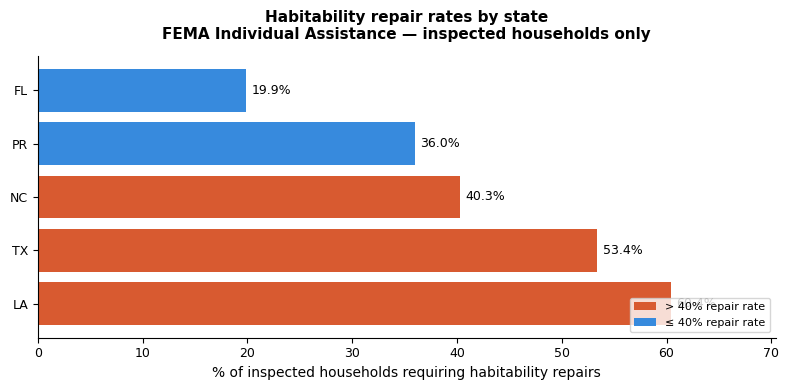

2026-03-31 00:49:21,183 | INFO | Saved figure: figures/repair_rate_by_state.png


INFO:fema_pipeline:Saved figure: figures/repair_rate_by_state.png


  Saved: figures/repair_rate_by_state.png

── Query 2: Damage type breakdown ──
2026-03-31 00:49:21,186 | INFO | Running query: damage type breakdown


INFO:fema_pipeline:Running query: damage type breakdown



── Damage types: repairs required vs not ──
 repairs_required       n  pct_flood  pct_foundation  pct_roof  pct_destroyed  avg_water_level  avg_rpfvl
                0 1402478        4.2             0.7       5.2            0.0             0.45     125.92
                1  873339       28.9             2.9      18.2            1.3             5.39    5069.74


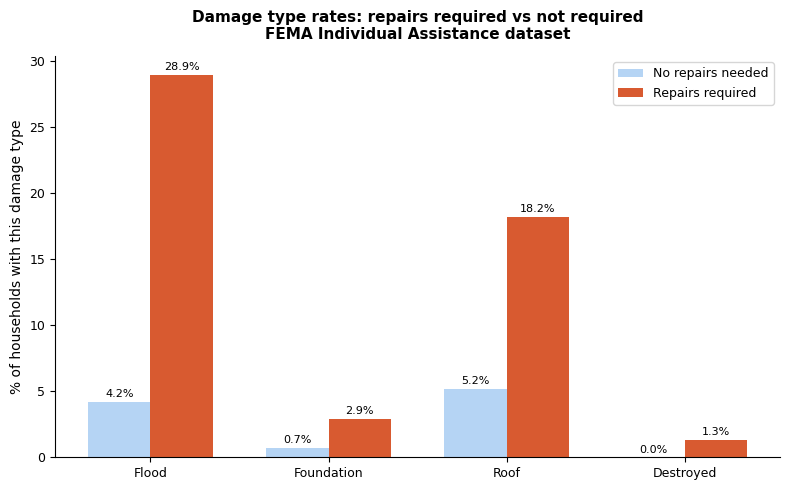

2026-03-31 00:49:21,852 | INFO | Saved figure: figures/damage_type_breakdown.png


INFO:fema_pipeline:Saved figure: figures/damage_type_breakdown.png


  Saved: figures/damage_type_breakdown.png

── Query 3: Income distribution by repair status ──
2026-03-31 00:49:21,856 | INFO | Running query: income by repair status


INFO:fema_pipeline:Running query: income by repair status


2026-03-31 00:49:22,812 | INFO | Income query returned 1,890,307 rows


INFO:fema_pipeline:Income query returned 1,890,307 rows


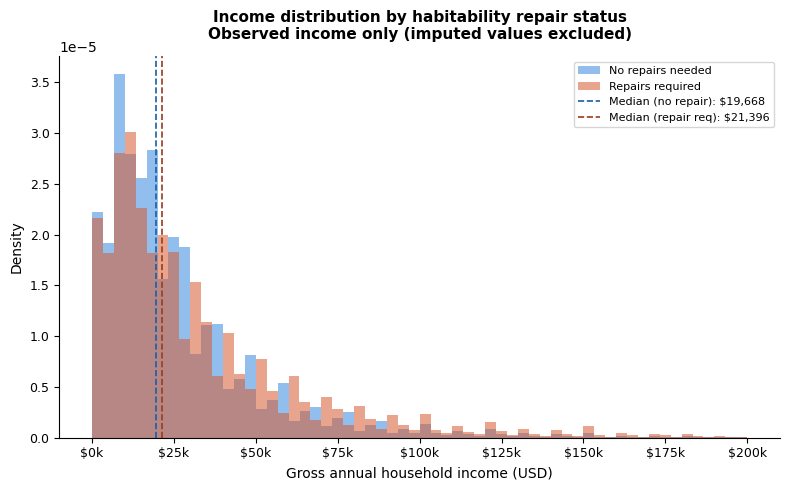

2026-03-31 00:49:24,143 | INFO | Saved figure: figures/income_vs_repair.png


INFO:fema_pipeline:Saved figure: figures/income_vs_repair.png


  Saved: figures/income_vs_repair.png

── Query 4: Repair rate by tenure ──
2026-03-31 00:49:24,146 | INFO | Running query: repair rate by tenure


INFO:fema_pipeline:Running query: repair rate by tenure



── Repair rate by tenure (owner vs renter) ──
ownRent   total  repairs_needed  repair_rate_pct  avg_income
  Owner 1279519        609686.0             47.6     50556.0
 Renter  982195        263650.0             26.8     31040.0

── Building ML feature matrix ──
2026-03-31 00:49:25,748 | INFO | Building ML feature matrix...


...


── ML feature matrix: 496,955 rows ──
 target      n  pct
      0 305540 61.5
      1 191415 38.5
2026-03-31 00:49:30,701 | INFO | ml_features exported: data/ml_features.csv (30.3 MB)


INFO:fema_pipeline:ml_features exported: data/ml_features.csv (30.3 MB)


  Exported ml_features.csv (30.3 MB)
2026-03-31 00:49:30,774 | INFO | analysis.py finished


INFO:fema_pipeline:analysis.py finished



✓ 3 figures saved to figures/
✓ ml_features.csv saved to data/
✓ Log updated in pipeline.log

Next step: run model.py


In [5]:

## ANALYSIS.PY — your version is already correct, no changes needed
## You already made the two right fixes:
##   1. matplotlib.use("Agg") is commented out ✓
##   2. save_fig() calls plt.show() before plt.close() ✓
## This version is included here just for completeness.

import duckdb
import logging
import os
import sys
import pandas as pd
import matplotlib
# matplotlib.use("Agg")  # commented out — not needed in Jupyter
import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH     = "fema.db"
LOG_PATH    = "pipeline.log"
FIGURES_DIR = "figures"
DATA_DIR    = "data"

# ── LOGGING (notebook-safe version) ──
logger = logging.getLogger("fema_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fh = logging.FileHandler(LOG_PATH)
fh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
sh = logging.StreamHandler(sys.stdout)
sh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
logger.addHandler(fh)
logger.addHandler(sh)


def connect(db_path: str) -> duckdb.DuckDBPyConnection:
    """Connect to fema.db."""
    try:
        con = duckdb.connect(db_path)
        logger.info(f"Connected to {db_path}")
        return con
    except Exception as e:
        logger.error(f"Connection failed: {e}")
        raise


def ensure_dirs() -> None:
    """Create output folders if they don't exist."""
    for d in [FIGURES_DIR, DATA_DIR]:
        os.makedirs(d, exist_ok=True)
    logger.info("Output directories ready")


def save_fig(filename: str) -> None:
    """Save figure to figures/ AND display inline in notebook."""
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")  # save first
    plt.show()                                         # then display
    plt.close()                                        # then clean up
    logger.info(f"Saved figure: {path}")
    print(f"  Saved: {path}")


def query_repair_rate_by_state(con: duckdb.DuckDBPyConnection) -> pd.DataFrame:
    """
    Joins damage_assessment + location to compute the percentage
    of inspected households requiring habitability repairs per state.
    Only includes states with at least 1,000 inspected households.
    """
    logger.info("Running query: repair rate by state")
    df = con.execute("""
        SELECT
            l.damagedStateAbbreviation AS state,
            COUNT(*) AS total,
            SUM(d.habitabilityRepairsRequired) AS repairs_needed,
            ROUND(SUM(d.habitabilityRepairsRequired)*100.0/COUNT(*), 1) AS repair_rate_pct
        FROM damage_assessment d
        JOIN location l ON d.id = l.id
        GROUP BY l.damagedStateAbbreviation
        HAVING COUNT(*) >= 1000
        ORDER BY repair_rate_pct DESC
    """).df()
    print("\n── Habitability repair rate by state ──")
    print(df.to_string(index=False))
    return df


def plot_repair_rate_by_state(df: pd.DataFrame) -> None:
    """Horizontal bar chart of repair rates by state."""
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["#D85A30" if r > 40 else "#378ADD" for r in df["repair_rate_pct"]]
    bars = ax.barh(df["state"], df["repair_rate_pct"], color=colors, edgecolor="none")
    for bar, val in zip(bars, df["repair_rate_pct"]):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                f"{val}%", va="center", ha="left", fontsize=9)
    ax.set_xlabel("% of inspected households requiring habitability repairs", fontsize=10)
    ax.set_title("Habitability repair rates by state\nFEMA Individual Assistance — inspected households only",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_xlim(0, df["repair_rate_pct"].max() + 10)
    ax.spines[["top","right"]].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor="#D85A30", label="> 40% repair rate"),
                       Patch(facecolor="#378ADD", label="≤ 40% repair rate")],
              fontsize=8, loc="lower right")
    plt.tight_layout()
    save_fig("repair_rate_by_state.png")


def query_damage_type_breakdown(con: duckdb.DuckDBPyConnection) -> pd.DataFrame:
    """
    Computes damage type rates for households with vs without habitability repairs.
    Shows which damage types are most predictive of repair needs.
    """
    logger.info("Running query: damage type breakdown")
    df = con.execute("""
        SELECT
            habitabilityRepairsRequired AS repairs_required,
            COUNT(*) AS n,
            ROUND(AVG(floodDamage)*100, 1)     AS pct_flood,
            ROUND(AVG(foundationDamage)*100, 1) AS pct_foundation,
            ROUND(AVG(roofDamage)*100, 1)      AS pct_roof,
            ROUND(AVG(destroyed)*100, 1)       AS pct_destroyed,
            ROUND(AVG(CAST(waterLevel AS DOUBLE)), 2) AS avg_water_level,
            ROUND(AVG(rpfvl), 2)               AS avg_rpfvl
        FROM damage_assessment
        GROUP BY habitabilityRepairsRequired
        ORDER BY habitabilityRepairsRequired
    """).df()
    print("\n── Damage types: repairs required vs not ──")
    print(df.to_string(index=False))
    return df


def plot_damage_type_breakdown(df: pd.DataFrame) -> None:
    """Grouped bar chart comparing damage type rates by repair status."""
    damage_types = ["pct_flood","pct_foundation","pct_roof","pct_destroyed"]
    labels       = ["Flood","Foundation","Roof","Destroyed"]
    no_repair  = df[df["repairs_required"]==0][damage_types].values[0]
    yes_repair = df[df["repairs_required"]==1][damage_types].values[0]
    x = range(len(labels)); width = 0.35
    fig, ax = plt.subplots(figsize=(8,5))
    ax.bar([i-width/2 for i in x], no_repair,  width, label="No repairs needed", color="#B5D4F4", edgecolor="none")
    ax.bar([i+width/2 for i in x], yes_repair, width, label="Repairs required",  color="#D85A30", edgecolor="none")
    ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("% of households with this damage type", fontsize=10)
    ax.set_title("Damage type rates: repairs required vs not required\nFEMA Individual Assistance dataset",
                 fontsize=11, fontweight="bold", pad=12)
    ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)
    for bars in ax.containers:
        ax.bar_label(bars, fmt="%.1f%%", fontsize=8, padding=2)
    plt.tight_layout()
    save_fig("damage_type_breakdown.png")


def query_income_by_repair_status(con: duckdb.DuckDBPyConnection) -> pd.DataFrame:
    """
    Joins registrants + damage_assessment to compare income distributions.
    Caps at $200k to remove extreme outliers. Excludes imputed income values.
    """
    logger.info("Running query: income by repair status")
    df = con.execute("""
        SELECT r.grossIncome, d.habitabilityRepairsRequired
        FROM registrants r
        JOIN damage_assessment d ON r.id = d.id
        WHERE r.grossIncome > 0
          AND r.grossIncome < 200000
          AND r.grossIncome_imputed = 0
    """).df()
    logger.info(f"Income query returned {len(df):,} rows")
    return df


def plot_income_vs_repair(df: pd.DataFrame) -> None:
    """Overlapping histogram of income by repair status with median lines."""
    fig, ax = plt.subplots(figsize=(8,5))
    no_repair  = df[df["habitabilityRepairsRequired"]==0]["grossIncome"]
    yes_repair = df[df["habitabilityRepairsRequired"]==1]["grossIncome"]
    ax.hist(no_repair,  bins=60, alpha=0.55, color="#378ADD", label="No repairs needed", density=True)
    ax.hist(yes_repair, bins=60, alpha=0.55, color="#D85A30", label="Repairs required",  density=True)
    ax.axvline(no_repair.median(),  color="#185FA5", linestyle="--", linewidth=1.2,
               label=f"Median (no repair): ${no_repair.median():,.0f}")
    ax.axvline(yes_repair.median(), color="#993C1D", linestyle="--", linewidth=1.2,
               label=f"Median (repair req): ${yes_repair.median():,.0f}")
    ax.set_xlabel("Gross annual household income (USD)", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_title("Income distribution by habitability repair status\nObserved income only (imputed values excluded)",
                 fontsize=11, fontweight="bold", pad=12)
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    plt.tight_layout()
    save_fig("income_vs_repair.png")


def query_repair_by_tenure(con: duckdb.DuckDBPyConnection) -> pd.DataFrame:
    """
    Joins registrants + damage_assessment to compare repair rates
    between owners and renters.
    """
    logger.info("Running query: repair rate by tenure")
    df = con.execute("""
        SELECT r.ownRent, COUNT(*) AS total,
               SUM(d.habitabilityRepairsRequired) AS repairs_needed,
               ROUND(SUM(d.habitabilityRepairsRequired)*100.0/COUNT(*), 1) AS repair_rate_pct,
               ROUND(AVG(r.grossIncome), 0) AS avg_income
        FROM registrants r
        JOIN damage_assessment d ON r.id = d.id
        WHERE r.ownRent IN ('Owner','Renter')
        GROUP BY r.ownRent
        ORDER BY repair_rate_pct DESC
    """).df()
    print("\n── Repair rate by tenure (owner vs renter) ──")
    print(df.to_string(index=False))
    return df


def build_ml_features(con: duckdb.DuckDBPyConnection) -> None:
    """
    Joins all 4 tables and builds the ML feature matrix.

    Feature engineering decisions:
    - ownRent encoded as binary (1=Owner, 0=Renter)
    - residenceType one-hot encoded (house/duplex as baseline)
    - Binary damage flags kept as-is (already 0/1)
    - Dollar amounts kept as continuous features
    - grossIncome_imputed flag retained for model signal
    - Sampled to 500,000 rows for training speed
    Target: habitabilityRepairsRequired (0 or 1)
    """
    logger.info("Building ML feature matrix...")
    con.execute("""
        CREATE OR REPLACE TABLE ml_features AS
        SELECT
            d.habitabilityRepairsRequired AS target,
            r.householdComposition, r.grossIncome, r.grossIncome_imputed, r.specialNeeds,
            CASE WHEN r.ownRent='Owner' THEN 1 WHEN r.ownRent='Renter' THEN 0 ELSE NULL END AS is_owner,
            CASE WHEN r.residenceType='House/Duplex' THEN 1 ELSE 0 END AS res_house,
            CASE WHEN r.residenceType='Apartment'    THEN 1 ELSE 0 END AS res_apartment,
            CASE WHEN r.residenceType='Mobile Home'  THEN 1 ELSE 0 END AS res_mobile,
            CASE WHEN r.residenceType='Townhouse'    THEN 1 ELSE 0 END AS res_townhouse,
            r.homeOwnersInsurance, r.floodInsurance, r.primaryResidence,
            d.waterLevel, d.floodDamage, d.foundationDamage, d.foundationDamageAmount,
            d.roofDamage, d.roofDamageAmount, d.rpfvl, d.ppfvl, d.destroyed,
            l.damagedStateAbbreviation AS state
        FROM damage_assessment d
        JOIN registrants r ON d.id = r.id
        JOIN location l    ON d.id = l.id
        WHERE d.habitabilityRepairsRequired IS NOT NULL
          AND r.ownRent IN ('Owner','Renter')
          AND r.grossIncome IS NOT NULL
        USING SAMPLE 500000
    """)
    n = con.execute("SELECT COUNT(*) FROM ml_features").fetchone()[0]
    target_dist = con.execute("""
        SELECT target, COUNT(*) as n,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) as pct
        FROM ml_features GROUP BY target ORDER BY target
    """).df()
    print(f"\n── ML feature matrix: {n:,} rows ──")
    print(target_dist.to_string(index=False))

    out_path = os.path.join(DATA_DIR, "ml_features.csv")
    con.execute(f"COPY ml_features TO '{out_path}' (HEADER, DELIMITER ',')")
    size_mb = os.path.getsize(out_path) / (1024 * 1024)
    logger.info(f"ml_features exported: {out_path} ({size_mb:.1f} MB)")
    print(f"  Exported ml_features.csv ({size_mb:.1f} MB)")


def main():
    logger.info("analysis.py started...")
    ensure_dirs()
    con = connect(DB_PATH)

    print("\n── Query 1: Repair rate by state ──")
    df_state = query_repair_rate_by_state(con)
    plot_repair_rate_by_state(df_state)

    print("\n── Query 2: Damage type breakdown ──")
    df_damage = query_damage_type_breakdown(con)
    plot_damage_type_breakdown(df_damage)

    print("\n── Query 3: Income distribution by repair status ──")
    df_income = query_income_by_repair_status(con)
    plot_income_vs_repair(df_income)

    print("\n── Query 4: Repair rate by tenure ──")
    query_repair_by_tenure(con)

    print("\n── Building ML feature matrix ──")
    build_ml_features(con)

    con.close()
    logger.info("analysis.py finished")
    print("\n✓ 3 figures saved to figures/")
    print("✓ ml_features.csv saved to data/")
    print("✓ Log updated in pipeline.log")
    print("\nNext step: run model.py")


if __name__ == "__main__":
    main()

## 5. Build ML feature matrix and Train ML models

**Target:** `habitabilityRepairsRequired` (0 = no repairs, 1 = repairs required)

2026-03-31 00:49:31,931 | INFO | model.py started...


INFO:fema_pipeline:model.py started...



── Loading feature matrix ──
2026-03-31 00:49:32,942 | INFO | Loaded ml_features.csv: 496,955 rows, 23 columns


INFO:fema_pipeline:Loaded ml_features.csv: 496,955 rows, 23 columns


2026-03-31 00:49:33,163 | INFO | Feature matrix ready: 496,955 rows


...

INFO:fema_pipeline:Train: 397,564 rows | Test: 99,391 rows


2026-03-31 00:50:13,846 | INFO | Random Forest training complete


INFO:fema_pipeline:Random Forest training complete



── Model 1: Random Forest Classifier ──
  Accuracy : 0.8113  (81.1%)
  F1 Score : 0.7550

  Classification report:
                  precision    recall  f1-score   support

      No repairs       0.85      0.85      0.85     61108
Repairs required       0.76      0.75      0.76     38283

        accuracy                           0.81     99391
       macro avg       0.80      0.80      0.80     99391
    weighted avg       0.81      0.81      0.81     99391

2026-03-31 00:50:14,658 | INFO | Classifier — Accuracy: 0.8113 | F1: 0.7550


INFO:fema_pipeline:Classifier — Accuracy: 0.8113 | F1: 0.7550


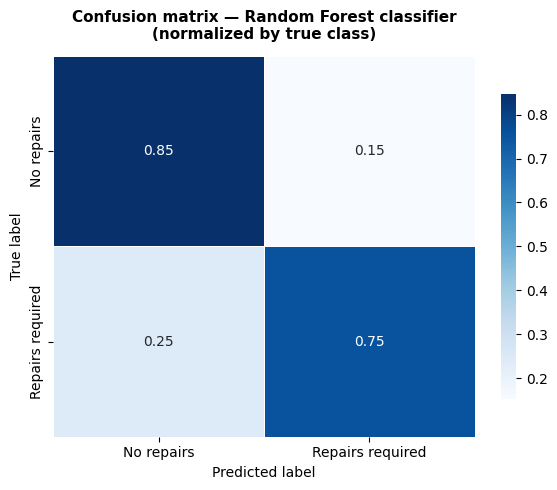

2026-03-31 00:50:15,001 | INFO | Saved figure: figures/confusion_matrix.png


INFO:fema_pipeline:Saved figure: figures/confusion_matrix.png


  Saved: figures/confusion_matrix.png


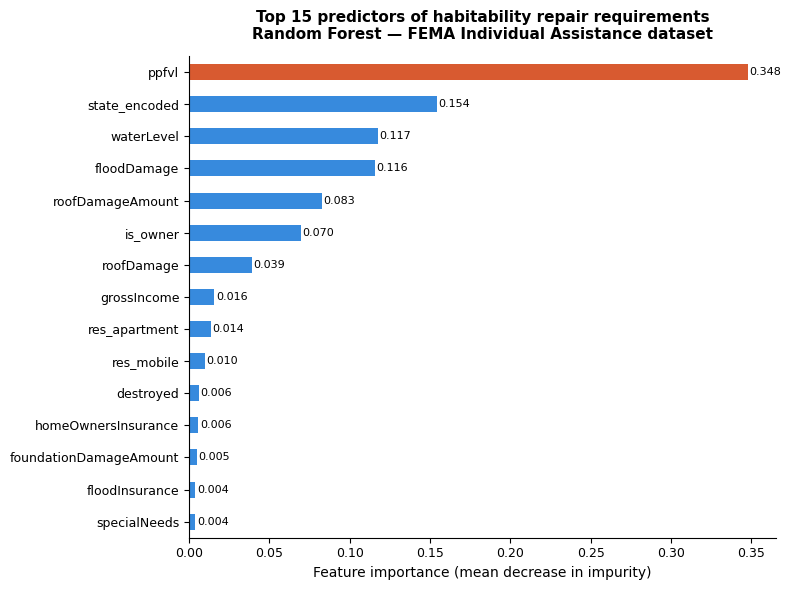

2026-03-31 00:50:15,658 | INFO | Saved figure: figures/feature_importance.png


INFO:fema_pipeline:Saved figure: figures/feature_importance.png


  Saved: figures/feature_importance.png
2026-03-31 00:50:15,666 | INFO | Training Gradient Boosting regressor...


INFO:fema_pipeline:Training Gradient Boosting regressor...


2026-03-31 00:50:15,709 | INFO | Regressor training set: 209,768 rows with rpfvl > 0


...

INFO:fema_pipeline:Subsampled to 100,000 rows for regressor training


2026-03-31 00:50:29,548 | INFO | Gradient Boosting training complete


INFO:fema_pipeline:Gradient Boosting training complete



── Model 2: Gradient Boosting Regressor ──
  R² Score        : 0.6609
  RMSE (log scale): 0.9835
  RMSE (dollars)  : $5,135
  Median actual   : $1,101
  Median predicted: $851
2026-03-31 00:50:29,605 | INFO | Regressor — R²: 0.6609 | RMSE: $5,135


INFO:fema_pipeline:Regressor — R²: 0.6609 | RMSE: $5,135


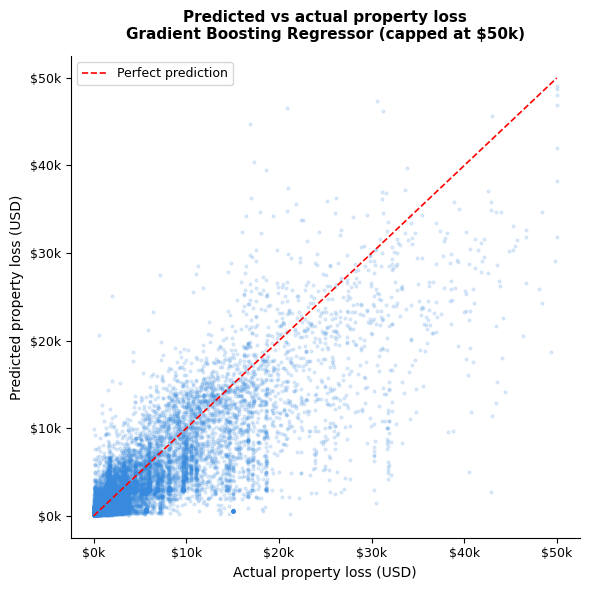

2026-03-31 00:50:30,387 | INFO | Saved figure: figures/predicted_vs_actual.png


INFO:fema_pipeline:Saved figure: figures/predicted_vs_actual.png


  Saved: figures/predicted_vs_actual.png
2026-03-31 00:50:30,392 | INFO | model.py finished


INFO:fema_pipeline:model.py finished



✓ Models trained successfully
✓ Figures saved to figures/
✓ Log updated in pipeline.log

All Python scripts complete!


In [6]:

## MODEL.PY — two changes: logging fix + plt.show() added
## WHAT CHANGED:
##   1. Replaced logging.basicConfig with named logger (same as others)
##   2. matplotlib.use("Agg") commented out
##   3. save_fig() now calls plt.show() before plt.close()
##      so plots display inline in Jupyter AND save to disk
## Everything else is identical to your working version.

import duckdb
import logging
import os
import sys
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use("Agg")  # commented out — not needed in Jupyter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    mean_squared_error, r2_score
)
from sklearn.preprocessing   import LabelEncoder

DB_PATH      = "fema.db"
LOG_PATH     = "pipeline.log"
FIGURES_DIR  = "figures"
DATA_DIR     = "data"
RANDOM_STATE = 42

# ── LOGGING (notebook-safe version) ──
logger = logging.getLogger("fema_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fh = logging.FileHandler(LOG_PATH)
fh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
sh = logging.StreamHandler(sys.stdout)
sh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
logger.addHandler(fh)
logger.addHandler(sh)


def save_fig(filename: str) -> None:
    """Save figure to figures/ AND display inline in notebook."""
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")  # save first
    plt.show()                                         # then display
    plt.close()                                        # then clean up
    logger.info(f"Saved figure: {path}")
    print(f"  Saved: {path}")


def load_features() -> pd.DataFrame:
    """
    Loads ml_features.csv produced by analysis.py.
    Encodes state column as integers for sklearn.
    Drops any remaining null rows.
    """
    path = os.path.join(DATA_DIR, "ml_features.csv")
    try:
        df = pd.read_csv(path)
        logger.info(f"Loaded ml_features.csv: {len(df):,} rows, {len(df.columns)} columns")
    except FileNotFoundError:
        logger.error("ml_features.csv not found — run analysis.py first")
        raise
    le = LabelEncoder()
    df["state_encoded"] = le.fit_transform(df["state"].astype(str))
    df = df.drop(columns=["state"])
    before = len(df)
    df = df.dropna()
    after  = len(df)
    if before - after > 0:
        logger.warning(f"Dropped {before-after} rows with remaining nulls")
    logger.info(f"Feature matrix ready: {len(df):,} rows")
    return df


def train_classifier(df: pd.DataFrame) -> tuple:
    """
    Trains a Random Forest classifier to predict habitabilityRepairsRequired.

    Key decisions:
    - class_weight='balanced': corrects for 61/39 class imbalance
    - n_estimators=100: standard starting point
    - max_depth=10: prevents overfitting on 500k row dataset
    - test_size=0.2: 80/20 train/test split
    - random_state=42: reproducible results
    """
    logger.info("Training Random Forest classifier...")
    drop_cols = ["target","rpfvl"]
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["target"].astype(int)
    feature_names = X.columns.tolist()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    logger.info(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
    clf = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    )
    clf.fit(X_train, y_train)
    logger.info("Random Forest training complete")
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    print(f"\n── Model 1: Random Forest Classifier ──")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  F1 Score : {f1:.4f}")
    print(f"\n  Classification report:")
    print(classification_report(y_test, y_pred, target_names=["No repairs","Repairs required"]))
    logger.info(f"Classifier — Accuracy: {acc:.4f} | F1: {f1:.4f}")
    return clf, X_test, y_test, y_pred, feature_names


def plot_confusion_matrix(y_test, y_pred) -> None:
    """
    Normalized confusion matrix.
    Rationale: normalization shows prediction *rates* not raw counts,
    more meaningful for comparing performance across classes at 500k scale.
    """
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    labels = ["No repairs","Repairs required"]
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5, cbar_kws={"shrink":0.8})
    ax.set_xlabel("Predicted label", fontsize=10)
    ax.set_ylabel("True label", fontsize=10)
    ax.set_title("Confusion matrix — Random Forest classifier\n(normalized by true class)",
                 fontsize=11, fontweight="bold", pad=12)
    plt.tight_layout()
    save_fig("confusion_matrix.png")


def plot_feature_importance(clf, feature_names: list) -> None:
    """
    Top 15 feature importances from Random Forest.
    Rationale: shows which household and damage characteristics most
    strongly predict repair needs. Core analytical result of this project.
    Feature importance = mean decrease in impurity across all trees.
    """
    importances = pd.Series(
        clf.feature_importances_, index=feature_names
    ).sort_values(ascending=True).tail(15)
    fig, ax = plt.subplots(figsize=(8,6))
    colors = ["#D85A30" if i >= importances.max()*0.5 else "#378ADD" for i in importances]
    importances.plot(kind="barh", ax=ax, color=colors, edgecolor="none")
    ax.set_xlabel("Feature importance (mean decrease in impurity)", fontsize=10)
    ax.set_title("Top 15 predictors of habitability repair requirements\nRandom Forest — FEMA Individual Assistance dataset",
                 fontsize=11, fontweight="bold", pad=12)
    ax.spines[["top","right"]].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)
    for i, (val, name) in enumerate(zip(importances.values, importances.index)):
        ax.text(val+0.001, i, f"{val:.3f}", va="center", fontsize=8)
    plt.tight_layout()
    save_fig("feature_importance.png")


def train_regressor(df: pd.DataFrame) -> None:
    """
    Gradient Boosting regressor predicting rpfvl (property damage $).

    Key decisions:
    - Filter to rpfvl > 0: only households with actual recorded damage
    - log1p transform: rpfvl is right-skewed; log stabilizes variance
    - max_depth=4, subsample=0.8: conservative to avoid overfitting
    - 100k row subsample: regressor is slower than classifier
    """
    logger.info("Training Gradient Boosting regressor...")
    df_reg = df[df["rpfvl"] > 0].copy()
    logger.info(f"Regressor training set: {len(df_reg):,} rows with rpfvl > 0")
    df_reg["rpfvl_log"] = np.log1p(df_reg["rpfvl"])
    if len(df_reg) > 100000:
        df_reg = df_reg.sample(100000, random_state=RANDOM_STATE)
        logger.info("Subsampled to 100,000 rows for regressor training")
    drop_cols = ["target","rpfvl","rpfvl_log"]
    X = df_reg.drop(columns=[c for c in drop_cols if c in df_reg.columns])
    y = df_reg["rpfvl_log"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    reg = GradientBoostingRegressor(
        n_estimators=100, max_depth=4,
        learning_rate=0.1, subsample=0.8,
        random_state=RANDOM_STATE
    )
    reg.fit(X_train, y_train)
    logger.info("Gradient Boosting training complete")
    y_pred_log     = reg.predict(X_test)
    rmse_log       = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2             = r2_score(y_test, y_pred_log)
    y_pred_dollars = np.expm1(y_pred_log)
    y_test_dollars = np.expm1(y_test)
    rmse_dollars   = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
    print(f"\n── Model 2: Gradient Boosting Regressor ──")
    print(f"  R² Score        : {r2:.4f}")
    print(f"  RMSE (log scale): {rmse_log:.4f}")
    print(f"  RMSE (dollars)  : ${rmse_dollars:,.0f}")
    print(f"  Median actual   : ${y_test_dollars.median():,.0f}")
    print(f"  Median predicted: ${pd.Series(y_pred_dollars).median():,.0f}")
    logger.info(f"Regressor — R²: {r2:.4f} | RMSE: ${rmse_dollars:,.0f}")
    plot_predicted_vs_actual(y_test_dollars, y_pred_dollars)


def plot_predicted_vs_actual(y_test, y_pred) -> None:
    """
    Predicted vs actual property loss, capped at $50k.
    Rationale: standard regression evaluation plot. Points near the
    diagonal = accurate predictions. Cap removes extreme outliers
    that compress the scale and hide the main distribution.
    """
    y_test = pd.Series(y_test).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    mask   = (y_test < 50000) & (y_pred < 50000)
    y_t    = y_test[mask]; y_p = y_pred[mask]
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(y_t, y_p, alpha=0.15, s=4, color="#378ADD", rasterized=True)
    max_val = max(y_t.max(), y_p.max())
    ax.plot([0,max_val],[0,max_val],"r--",linewidth=1.2,label="Perfect prediction")
    ax.set_xlabel("Actual property loss (USD)", fontsize=10)
    ax.set_ylabel("Predicted property loss (USD)", fontsize=10)
    ax.set_title("Predicted vs actual property loss\nGradient Boosting Regressor (capped at $50k)",
                 fontsize=11, fontweight="bold", pad=12)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)
    plt.tight_layout()
    save_fig("predicted_vs_actual.png")


def main():
    logger.info("model.py started...")
    os.makedirs(FIGURES_DIR, exist_ok=True)
    print("\n── Loading feature matrix ──")
    df = load_features()
    clf, X_test, y_test, y_pred, feature_names = train_classifier(df)
    plot_confusion_matrix(y_test, y_pred)
    plot_feature_importance(clf, feature_names)
    train_regressor(df)
    logger.info("model.py finished")
    print("\n✓ Models trained successfully")
    print("✓ Figures saved to figures/")
    print("✓ Log updated in pipeline.log")
    print("\nAll Python scripts complete!")


if __name__ == "__main__":
    main()

# Results Summary

| Model | Task | Performance |
| --- | --- | --- |
| **Random Forest Classifier** | Predict habitability repairs (0/1) | **81.1% accuracy**, **F1 = 0.755** |
| **Gradient Boosting Regressor** | Predict property loss| **R2 = 0.661**, **RMSE = $5,135** |



The classification model significantly outperforms a naive baseline of 61.5% (predicting no repairs for all households), demonstrating that FEMA registration and inspection data contain meaningful predictive signals for early intervention.

## Key Insights from Data

### 1. Geographic Disparities in Damage
- Louisiana (LA) experienced the highest repair rate: 60.4%
- Compared to Florida (FL): 19.9%
- Texas also showed elevated damage levels: 53.4%

> 👉 This suggests disaster impact is highly region-dependent, likely reflecting storm intensity and infrastructure vulnerability.

### 2. Flood Damage is the Strongest Predictor
- Households requiring repairs:
  - 28.9% flood damage rate
- Households not requiring repairs:
  - 4.2% flood damage rate

> 👉 This is nearly a 7x increase, making flood exposure the single most important risk factor for habitability failure.

Additional signals include:
- Roof damage: 18.2% vs 5.2%
- Foundation damage: 2.9% vs 0.7%
- Water level: 5.39 vs 0.45

### 3. Owners are More Likely to Require Repairs
- Owners: 47.6% repair rate
- Renters: 26.8% repair rate

> 👉 This may reflect:
> - Larger property exposure
> - Structural responsibility differences
> - Higher likelihood of reporting/inspection for owned homes.

### 4. Property Loss is Highly Skewed
- Average loss (repairs required): $5,069

- Average loss (no repairs): $126

- Median actual loss: $1,101

>
> 👉 The distribution is heavily right-skewed, which justifies:
>- Log transformation in regression model;
>- Use of RMSE alongside R2.

## Model Interpretation
### Classification Model (Random Forest)
Strong performance (F1 = 0.755) indicates balanced precision/recall.
successfully captures nonlinear relationships between:
damage indicators,
income,
housing type.
paticularly effective given class imbalance (61.5% vs 38.5%).

This model is suitable for triage decisions (who needs inspection priority).
the regression model (gradient boosting)
explains 66% of variance in property loss.
rMSE of ~$5k is reasonable given:
high variance in disaster damage,
extreme outliers in property loss.
the model is effective for estimating severity, not exact dollar prediction.
disaster recovery outcomes are predictable at registration time, providing a strong foundation for decision-support systems in emergency management.

## **How the Pipeline Solves the Problem**

The goal of this project is to shift FEMA’s housing assistance process from a **reactive, inspection-based system** to a **predictive triage system**. The pipeline operationalizes this shift across five key stages:

### **1\. Data Transformation: From Raw Records to Decision Systems**

The original FEMA dataset contains over **6.3 million records** in a flat structure. This pipeline restructures that data into a relational model with four specialized tables:

-   **`registrants`**: Household characteristics.
    
-   **`damage_assessment`**: Historical inspection outcomes.
    
-   **`assistance_outcomes`**: Final aid decisions.
    
-   **`location`**: Geographic and environmental context.
    

> **Impact:** This transformation enables efficient querying and scalable analysis, turning raw administrative data into a "decision-ready" dataset.

### **2\. Learning Historical Outcomes (Classification)**

Using the structured data, the pipeline trains a **Random Forest classifier** to predict the core decision FEMA inspectors currently make on-site:

-   **Target:** `habitabilityRepairsRequired` (Binary: 0/1)
    
-   **The Logic:** By mapping **registration-time features** $\rightarrow$ **inspection outcomes**, the model replicates the decision process in advance.
    

### **3\. Quantifying Severity (Regression)**

A secondary model (**Gradient Boosting Regressor**) predicts the financial scale of the impact:

-   **Target:** `rpfvl` (Real Property Federal Verified Loss in dollars)
    
-   **The Benefit:** This provides a continuous measure of damage, allowing FEMA to distinguish between minor and critical cases and prioritize by urgency.
    

### **4\. Enabling Predictive Triage (The Core Solution)**

Together, these models allow FEMA to move away from a "wait and see" approach.

| **Feature** | **Traditional Process** | **Predictive Pipeline** |
| --- | --- | --- |
| **Workflow** | Inspect $\rightarrow$ Decide | Predict $\rightarrow$ Prioritize $\rightarrow$ Act |
| **Speed** | Sequential & Reactive | Immediate & Proactive |
| **Resource Use** | First-come, first-served | High-risk households flagged first |

### **5\. Evidence of Efficacy**

The effectiveness of this approach is validated by strong model performance metrics:

-   **Classification:** **81.1% accuracy** ($F_1 = 0.755$) in predicting repair needs.
    
-   **Regression:** $R^2 = 0.66$ in estimating property loss.
    

* * *

## **Conclusion: Transforming Emergency Response**

The original problem was the inefficient allocation of emergency resources. This pipeline solves that by converting historical data into a predictive tool that reduces delays for households in need.

**The Bottom Line:** This project transforms emergency response from **sequential and reactive** to **prioritized and proactive.**

